In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = sns.load_dataset("mpg")
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


=== 1. Dimensiones ===
Filas y columnas: (398, 9)

=== Primeras filas ===
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  

=== Información de columnas y tipos de datos ===
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        

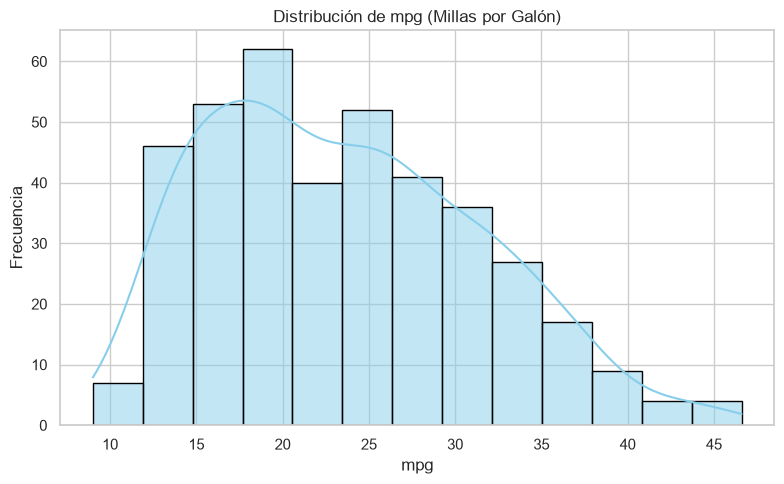

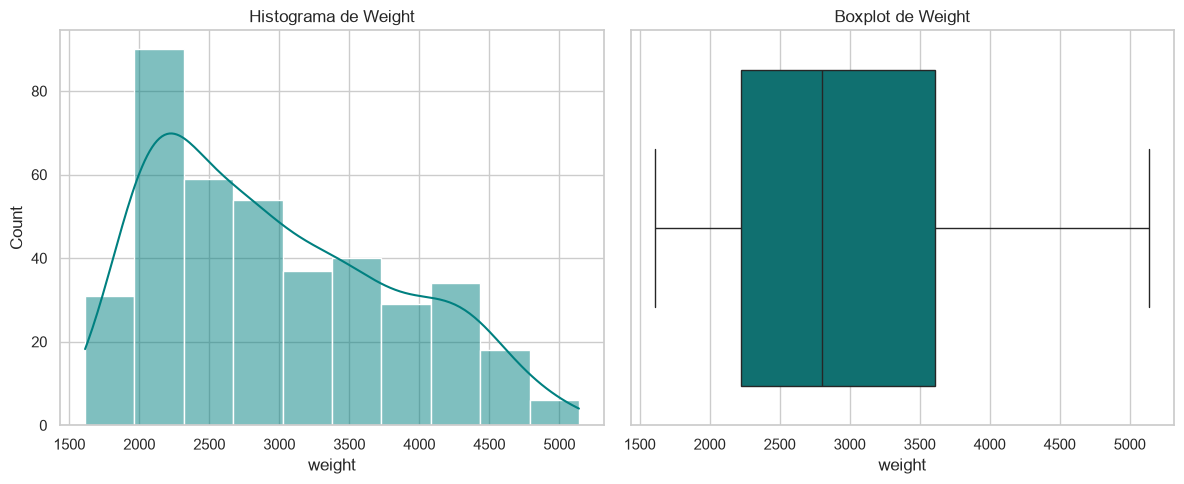


Límite superior IQR para weight: 5684.38
Outliers en weight: 0

=== 8. Vehículos detectados como outliers en horsepower ===
                             name  horsepower  cylinders  model_year
6                chevrolet impala       220.0          8          70
7               plymouth fury iii       215.0          8          70
8                pontiac catalina       225.0          8          70
13        buick estate wagon (sw)       225.0          8          70
25                      ford f250       215.0          8          70
27                     dodge d200       210.0          8          70
67                mercury marquis       208.0          8          72
94   chrysler new yorker brougham       215.0          8          73
95       buick electra 225 custom       225.0          8          73
116            pontiac grand prix       230.0          8          73


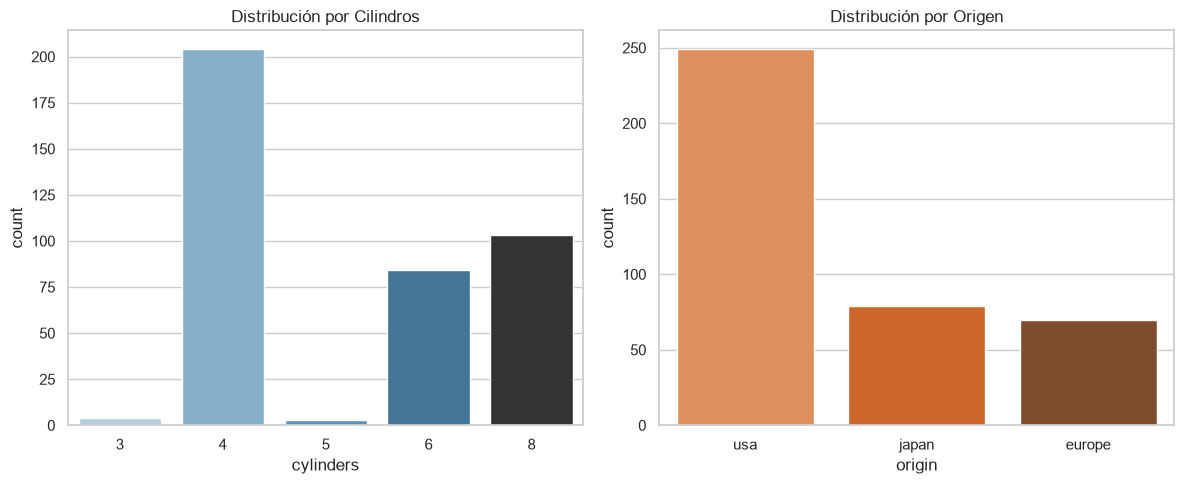

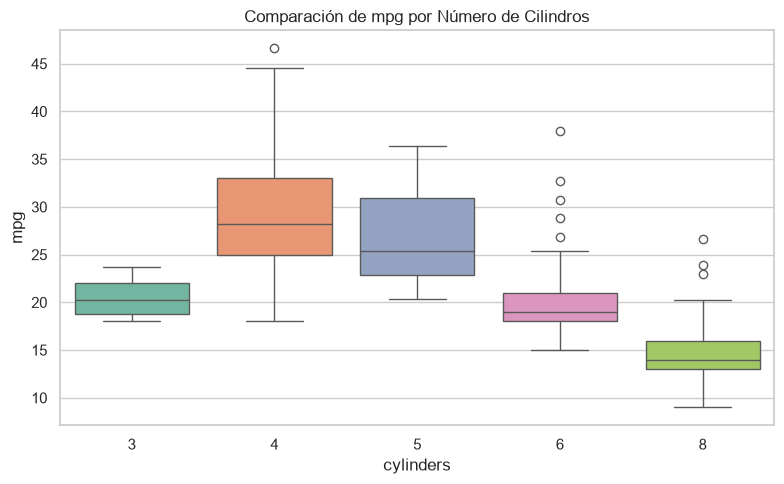


Medianas de mpg por cilindros:
cylinders
3    20.25
4    28.25
5    25.40
6    19.00
8    14.00
Name: mpg, dtype: float64


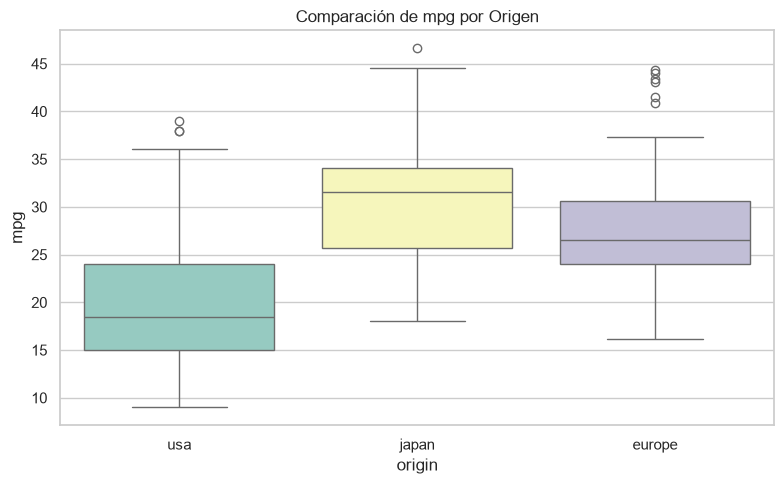

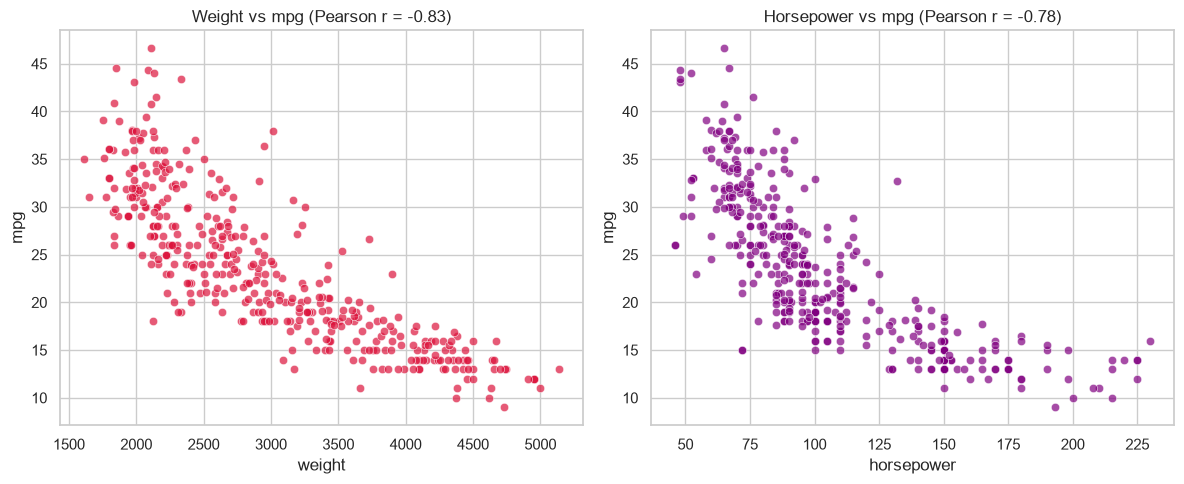

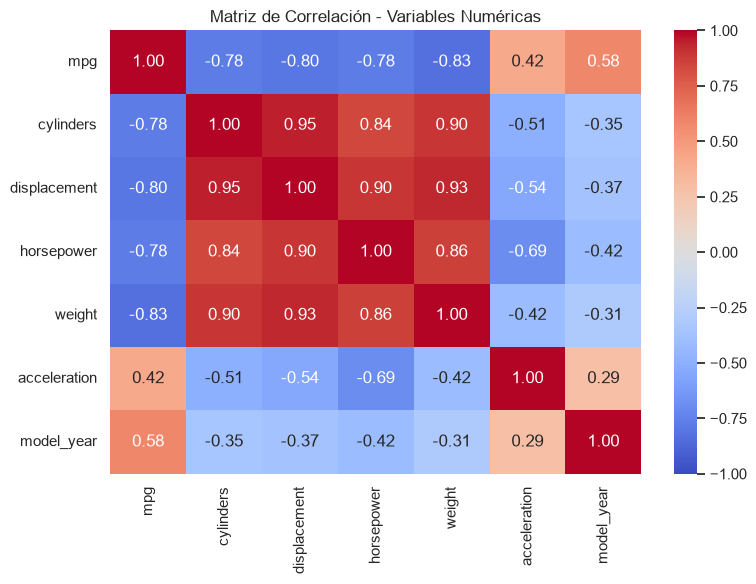

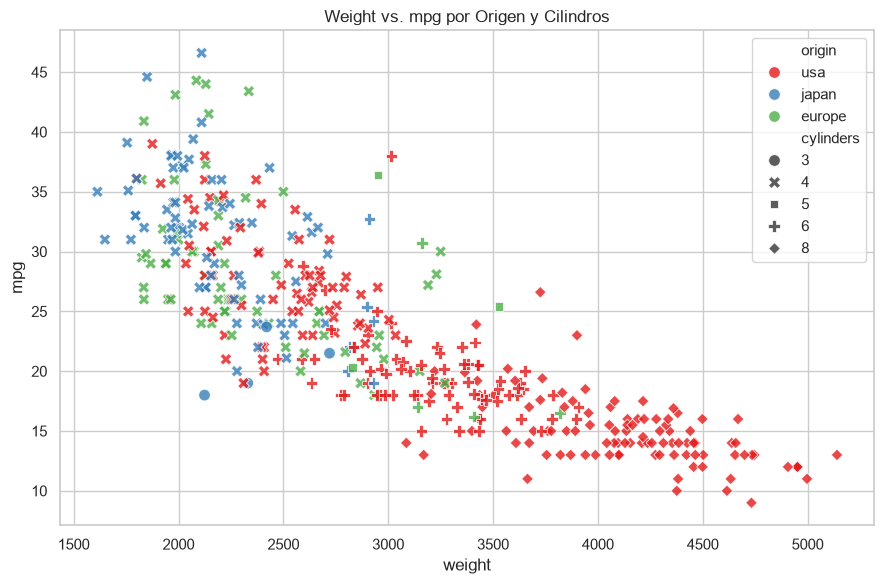

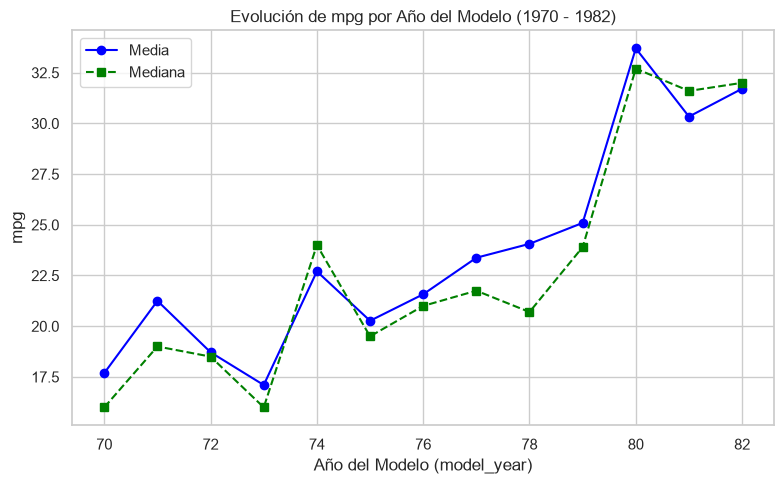

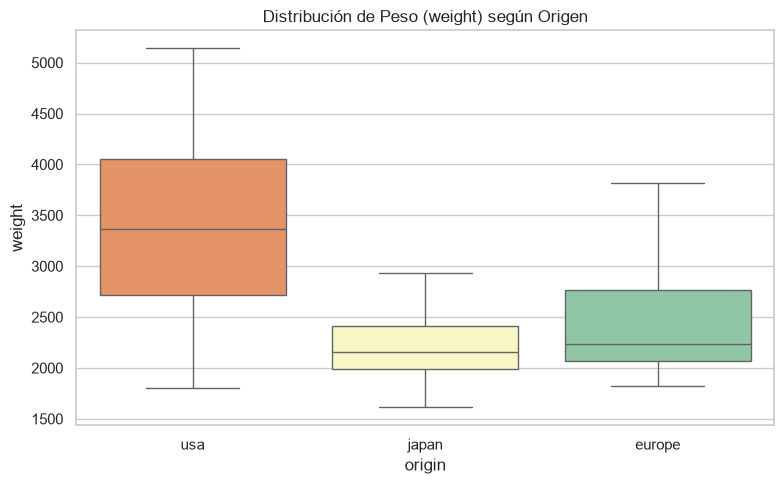


=== 18. Resumen de nulos por grupo ===
Nulos por Origen:
 origin
usa       4
europe    2
Name: count, dtype: int64
Nulos por Año:
 model_year
80    2
71    1
74    1
81    1
82    1
Name: count, dtype: int64


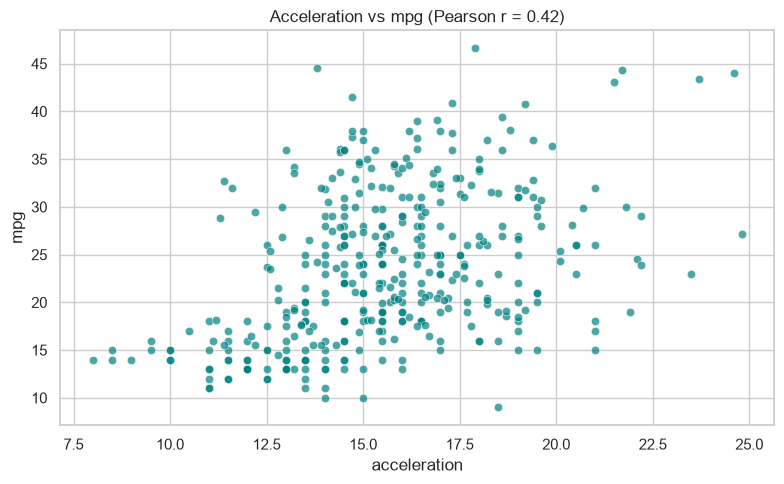

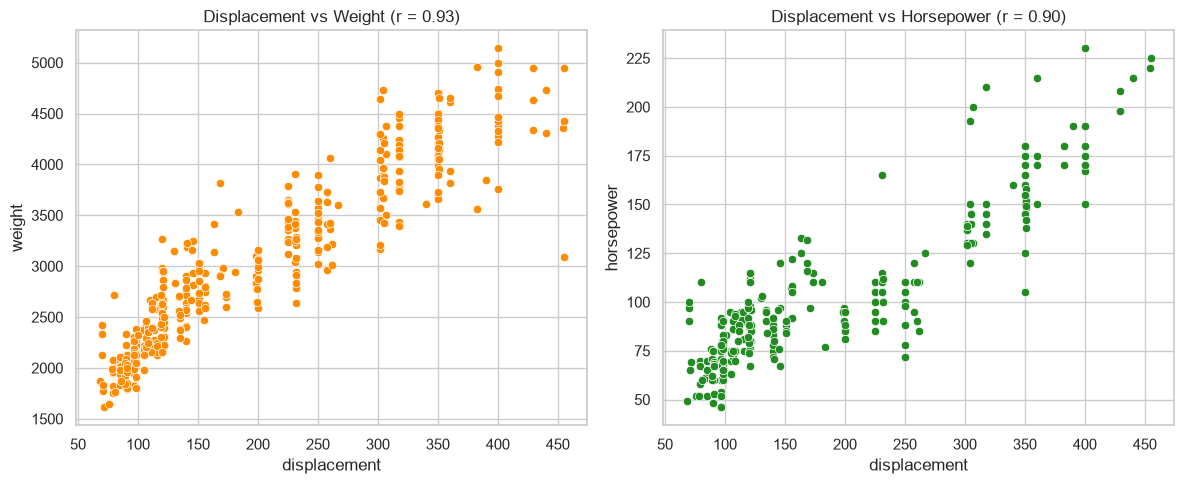


=== 21. Tabla Pivote (mpg Medio y Conteo por Grupo) ===
                mean                        count             
origin        europe      japan        usa europe japan    usa
cylinders                                                     
3                NaN  20.550000        NaN    NaN   4.0    NaN
4          28.411111  31.595652  27.840278   63.0  69.0   72.0
5          27.366667        NaN        NaN    3.0   NaN    NaN
6          20.100000  23.883333  19.663514    4.0   6.0   74.0
8                NaN        NaN  14.963107    NaN   NaN  103.0


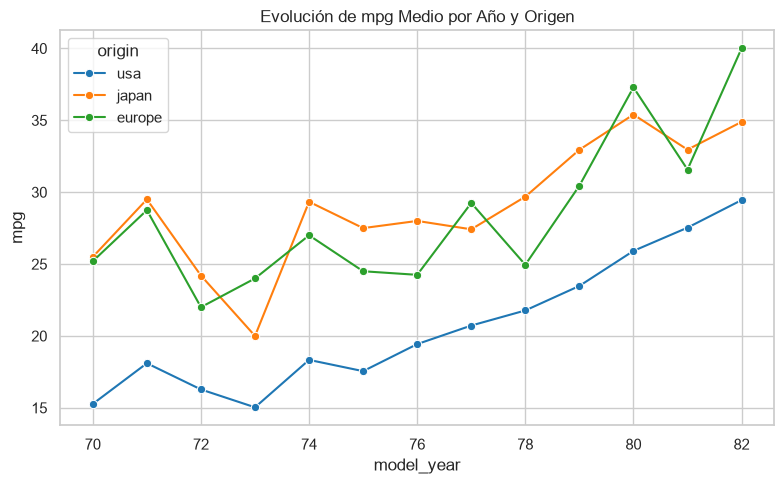


=== 23. Comparación de Métodos para Outliers en horsepower ===
Outliers detectados por 1.5-IQR: 10
Outliers detectados por Z-Score (|z| > 3): 5


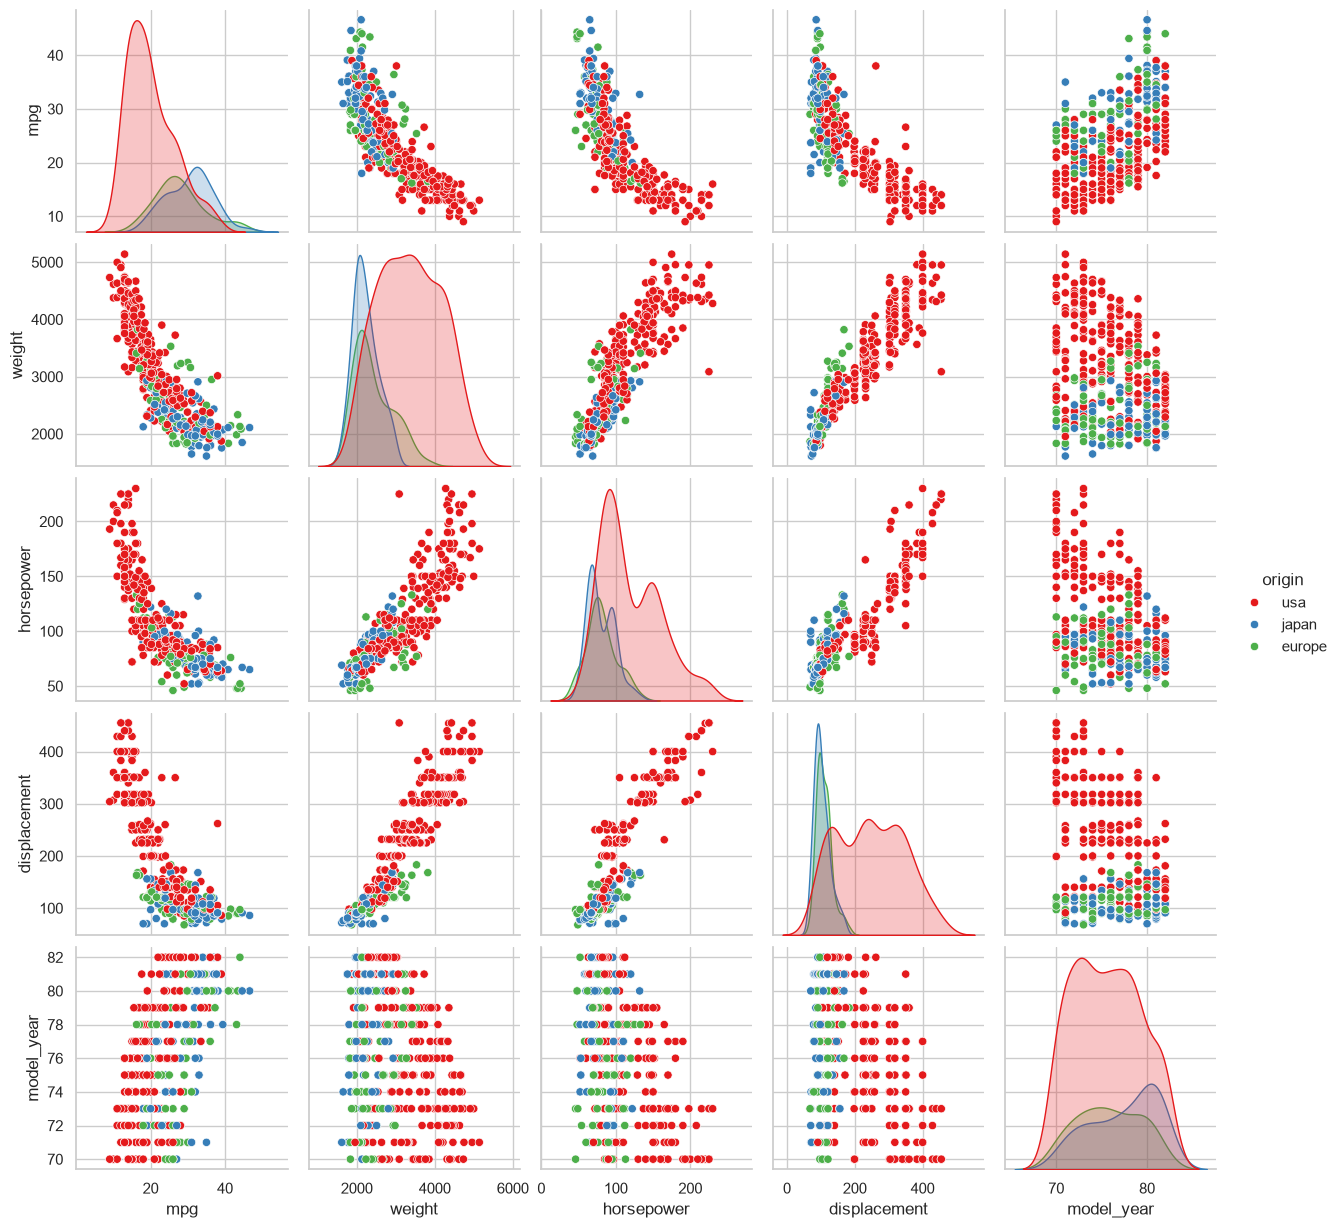


=== 25. REGISTRO DE DECISIONES (SUMMARY) ===
1. Impresión/Nulos:
   - Imputar los 6 nulos de 'horsepower' con la mediana agrupada por 'cylinders' y 'model_year'.
2. Outliers:
   - Conservar los outliers de potencia para el EDA (representan tecnología real V8).
   - Aplicar transformación logarítmica si se entrenan modelos lineales sensibles.
3. Multicolinealidad:
   - Eliminar 'displacement' o 'horsepower' si se entrena regresión lineal básica, dejando 'weight' como predictor clave.



In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuración inicial de visualizaciones
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

# ==============================================================================
# 1. CARGA Y PRIMER CONTACTO CON EL DATASET
# ==============================================================================
df

print('=== 1. Dimensiones ===')
print('Filas y columnas:', df.shape)

print('\n=== Primeras filas ===')
print(df.head())

print('\n=== Información de columnas y tipos de datos ===')
print(df.info())

# ==============================================================================
# 2. LIMPIEZA Y CLASIFICACIÓN DE VARIABLES
# ==============================================================================
# Convertir 'horsepower' a numérico tratando '?' como NaN
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# ==============================================================================
# 3. VALORES FALTANTES Y DUPLICADOS EXACTOS
# ==============================================================================
print('\n=== 3. Faltantes y Duplicados ===')
print('Duplicados exactos:', df.duplicated().sum())

nulos_hp = df['horsepower'].isnull().sum()
prop_hp = df['horsepower'].isnull().mean() * 100
print(f"Faltantes en 'horsepower': {nulos_hp} ({prop_hp:.2f}%)")

# ==============================================================================
# 4. CARDINALIDAD DE LA VARIABLE 'name'
# ==============================================================================
print('\n=== 4. Cardinalidad de name ===')
print('Nombres distintos de autos:', df['name'].nunique())

# Ejemplo de nombres repetidos con distintas configuraciones o años
print('\nEjemplo de modelos repetidos en el tiempo:')
print(
    df[df['name'] == 'ford pinto'][
        ['name', 'model_year', 'horsepower', 'weight', 'mpg']
    ]
)

# ==============================================================================
# 5. ESTADÍSTICOS DESCRIPTIVOS
# ==============================================================================
print('\n=== 5. Estadísticos Descriptivos (mpg, weight, horsepower) ===')
vars_num = ['mpg', 'weight', 'horsepower']
desc = df[vars_num].describe().T
desc['IQR'] = desc['75%'] - desc['25%']
print(desc[['mean', 'std', 'min', '25%', '50%', '75%', 'max', 'IQR']])

# ==============================================================================
# 6. DISTRIBUCIÓN DE 'mpg' (HISTOGRAMA Y KDE)
# ==============================================================================
plt.figure(figsize=(8, 5))
sns.histplot(df['mpg'], kde=True, color='skyblue', edgecolor='black')
plt.title('Distribución de mpg (Millas por Galón)')
plt.xlabel('mpg')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# ==============================================================================
# 7. ANÁLISIS DE 'weight' (HISTOGRAMA Y BOXPLOT)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['weight'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Histograma de Weight')

sns.boxplot(x=df['weight'], ax=axes[1], color='teal')
axes[1].set_title('Boxplot de Weight')
plt.tight_layout()
plt.show()

# Cálculo de regla IQR para 'weight'
q1_w = df['weight'].quantile(0.25)
q3_w = df['weight'].quantile(0.75)
iqr_w = q3_w - q1_w
lim_sup_w = q3_w + 1.5 * iqr_w
print(f'\nLímite superior IQR para weight: {lim_sup_w:.2f}')
print('Outliers en weight:', len(df[df['weight'] > lim_sup_w]))

# ==============================================================================
# 8. OUTLIERS EN 'horsepower' (1.5 IQR)
# ==============================================================================
q1_hp = df['horsepower'].quantile(0.25)
q3_hp = df['horsepower'].quantile(0.75)
iqr_hp = q3_hp - q1_hp
lim_sup_hp = q3_hp + 1.5 * iqr_hp

outliers_hp = df[df['horsepower'] > lim_sup_hp]
print('\n=== 8. Vehículos detectados como outliers en horsepower ===')
print(outliers_hp[['name', 'horsepower', 'cylinders', 'model_year']])

# ==============================================================================
# 9. FRECUENCIAS Y BARRAS DE 'cylinders' Y 'origin'
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(
    data=df,
    x='cylinders',
    ax=axes[0],
    hue='cylinders',
    palette='Blues_d',
    legend=False,
)
axes[0].set_title('Distribución por Cilindros')

sns.countplot(
    data=df,
    x='origin',
    ax=axes[1],
    hue='origin',
    palette='Oranges_d',
    legend=False,
)
axes[1].set_title('Distribución por Origen')
plt.tight_layout()
plt.show()

# ==============================================================================
# 10. COMPARACIÓN DE 'mpg' POR CILINDROS
# ==============================================================================
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x='cylinders',
    y='mpg',
    hue='cylinders',
    palette='Set2',
    legend=False,
)
plt.title('Comparación de mpg por Número de Cilindros')
plt.tight_layout()
plt.show()

print('\nMedianas de mpg por cilindros:')
print(df.groupby('cylinders')['mpg'].median())

# ==============================================================================
# 11. COMPARACIÓN DE 'mpg' POR ORIGEN
# ==============================================================================
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df, x='origin', y='mpg', hue='origin', palette='Set3', legend=False
)
plt.title('Comparación de mpg por Origen')
plt.tight_layout()
plt.show()

# ==============================================================================
# 12 Y 13. RELACIÓN WEIGHT / HORSEPOWER VS MPG (SCATTER & CORRELACIÓN)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

corr_w = df['weight'].corr(df['mpg'])
sns.scatterplot(
    data=df, x='weight', y='mpg', ax=axes[0], color='crimson', alpha=0.7
)
axes[0].set_title(f'Weight vs mpg (Pearson r = {corr_w:.2f})')

corr_hp = df['horsepower'].corr(df['mpg'])
sns.scatterplot(
    data=df, x='horsepower', y='mpg', ax=axes[1], color='purple', alpha=0.7
)
axes[1].set_title(f'Horsepower vs mpg (Pearson r = {corr_hp:.2f})')

plt.tight_layout()
plt.show()

# ==============================================================================
# 14. MATRIZ DE CORRELACIÓN Y HEATMAP
# ==============================================================================
cols_num = [
    'mpg',
    'cylinders',
    'displacement',
    'horsepower',
    'weight',
    'acceleration',
    'model_year',
]
corr_matrix = df[cols_num].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1
)
plt.title('Matriz de Correlación - Variables Numéricas')
plt.tight_layout()
plt.show()

# ==============================================================================
# 15. ANÁLISIS MULTIVARIADO (WEIGHT VS MPG POR ORIGEN)
# ==============================================================================
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='weight',
    y='mpg',
    hue='origin',
    style='cylinders',
    palette='Set1',
    s=70,
    alpha=0.8,
)
plt.title('Weight vs. mpg por Origen y Cilindros')
plt.tight_layout()
plt.show()

# ==============================================================================
# 16. EVOLUCIÓN TEMPORAL DE 'mpg' POR 'model_year'
# ==============================================================================
mpg_year = (
    df.groupby('model_year')['mpg'].agg(['mean', 'median']).reset_index()
)

plt.figure(figsize=(8, 5))
plt.plot(
    mpg_year['model_year'],
    mpg_year['mean'],
    label='Media',
    marker='o',
    color='blue',
)
plt.plot(
    mpg_year['model_year'],
    mpg_year['median'],
    label='Mediana',
    marker='s',
    linestyle='--',
    color='green',
)
plt.title('Evolución de mpg por Año del Modelo (1970 - 1982)')
plt.xlabel('Año del Modelo (model_year)')
plt.ylabel('mpg')
plt.legend()
plt.tight_layout()
plt.show()

# ==============================================================================
# 17. COMPARACIÓN DE 'weight' POR ORIGEN
# ==============================================================================
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x='origin',
    y='weight',
    hue='origin',
    palette='Spectral',
    legend=False,
)
plt.title('Distribución de Peso (weight) según Origen')
plt.tight_layout()
plt.show()

# ==============================================================================
# 18. PATRÓN DE VALORES FALTANTES EN 'horsepower'
# ==============================================================================
df_nulos = df[df['horsepower'].isnull()]
print('\n=== 18. Resumen de nulos por grupo ===')
print('Nulos por Origen:\n', df_nulos['origin'].value_counts())
print('Nulos por Año:\n', df_nulos['model_year'].value_counts())

# ==============================================================================
# 19. RELACIÓN 'acceleration' VS 'mpg'
# ==============================================================================
corr_acc = df['acceleration'].corr(df['mpg'])
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='acceleration', y='mpg', color='teal', alpha=0.7)
plt.title(f'Acceleration vs mpg (Pearson r = {corr_acc:.2f})')
plt.tight_layout()
plt.show()

# ==============================================================================
# 20. RELACIONES ENTRE PREDICTORES (REDUNDANCIA / MULTICOLINEALIDAD)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(
    data=df, x='displacement', y='weight', ax=axes[0], color='darkorange'
)
axes[0].set_title(
    f"Displacement vs Weight (r = {df['displacement'].corr(df['weight']):.2f})"
)

sns.scatterplot(
    data=df, x='displacement', y='horsepower', ax=axes[1], color='forestgreen'
)
axes[1].set_title(
    f"Displacement vs Horsepower (r = {df['displacement'].corr(df['horsepower']):.2f})"
)
plt.tight_layout()
plt.show()

# ==============================================================================
# 21. TABLA PIVOTE (mpg MEDIO Y CONTEO POR CILINDROS Y ORIGEN)
# ==============================================================================
pivot_table = df.pivot_table(
    index='cylinders', columns='origin', values='mpg', aggfunc=['mean', 'count']
)
print('\n=== 21. Tabla Pivote (mpg Medio y Conteo por Grupo) ===')
print(pivot_table)

# ==============================================================================
# 22. EVOLUCIÓN TEMPORAL DE 'mpg' POR ORIGEN
# ==============================================================================
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df,
    x='model_year',
    y='mpg',
    hue='origin',
    marker='o',
    errorbar=None,
    palette='tab10',
)
plt.title('Evolución de mpg Medio por Año y Origen')
plt.tight_layout()
plt.show()

# ==============================================================================
# 23. OUTLIERS EN 'horsepower' (CÁLCULO MANUAL DE Z-SCORE SIN SCIPI)
# ==============================================================================
hp_clean = df['horsepower'].dropna()

# Cálculo directo con Pandas y NumPy
mean_hp = hp_clean.mean()
std_hp = hp_clean.std(ddof=0)
z_scores = (hp_clean - mean_hp).abs() / std_hp
outliers_z = hp_clean[z_scores > 3]

print('\n=== 23. Comparación de Métodos para Outliers en horsepower ===')
print(f'Outliers detectados por 1.5-IQR: {len(outliers_hp)}')
print(f'Outliers detectados por Z-Score (|z| > 3): {len(outliers_z)}')

# ==============================================================================
# 24. PAIRPLOT MULTIVARIADO
# ==============================================================================
sns.pairplot(
    df[
        [
            'mpg',
            'weight',
            'horsepower',
            'displacement',
            'model_year',
            'origin',
        ]
    ],
    hue='origin',
    palette='Set1',
)
plt.show()

# ==============================================================================
# 25. REGISTRO DE DECISIONES DE PREPARACIÓN / MODELADO
# ==============================================================================
print("""
=== 25. REGISTRO DE DECISIONES (SUMMARY) ===
1. Impresión/Nulos:
   - Imputar los 6 nulos de 'horsepower' con la mediana agrupada por 'cylinders' y 'model_year'.
2. Outliers:
   - Conservar los outliers de potencia para el EDA (representan tecnología real V8).
   - Aplicar transformación logarítmica si se entrenan modelos lineales sensibles.
3. Multicolinealidad:
   - Eliminar 'displacement' o 'horsepower' si se entrena regresión lineal básica, dejando 'weight' como predictor clave.
""")